Введите радиус щётки (например 0.1):  0.02



=== Результаты обработки ===
Всего полигонов: 9
Радиус щётки: 0.02
Разделение на секции: Left (x ≤ 0.5), Middle (0.5 < x < 0.8), Right (x ≥ 0.8)



C:\Users\furmi\AppData\Local\Temp\ipykernel_62876\36842390.py:209: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', len(polygons))


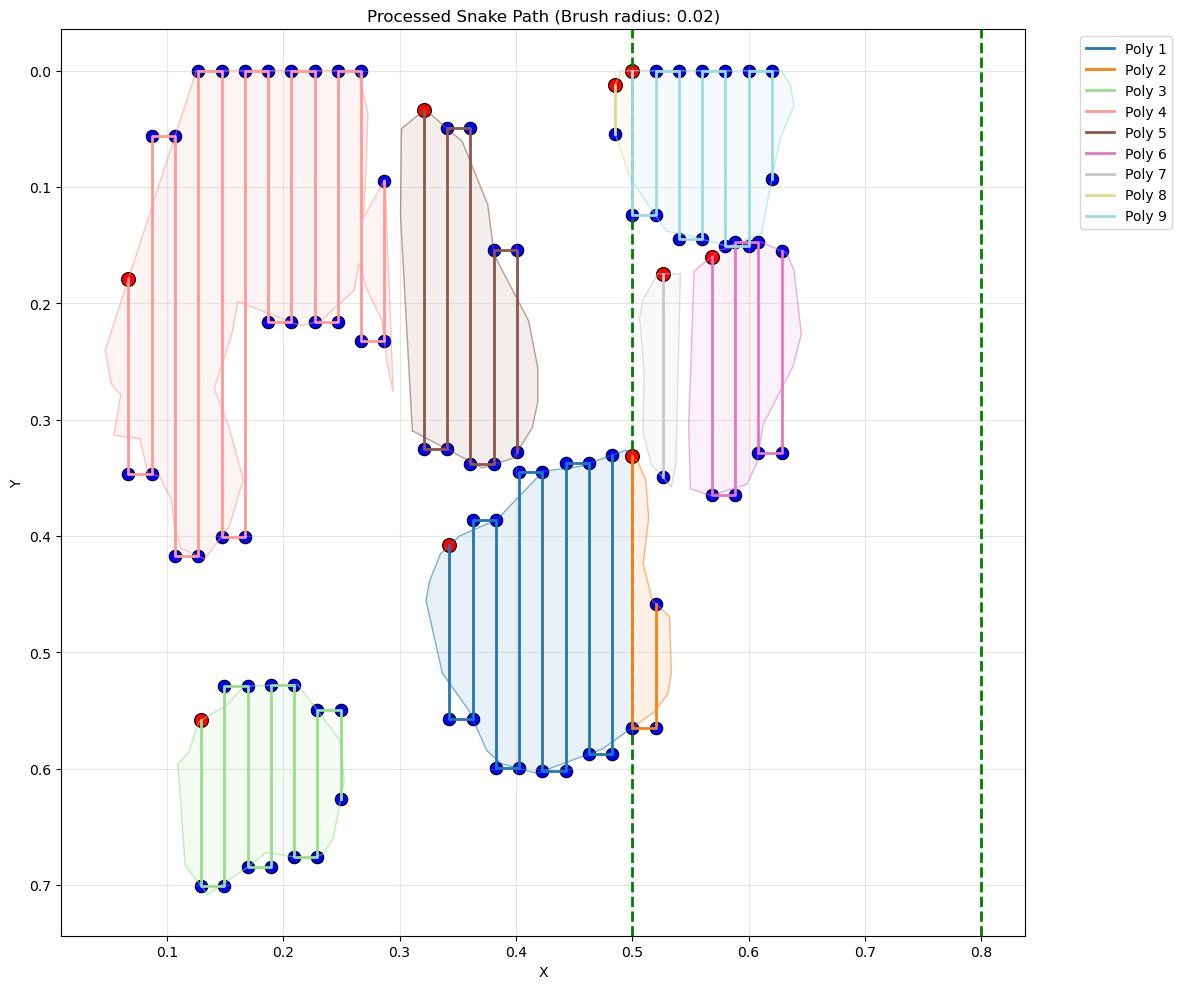


=== Обработанные координаты точек маршрутов ===

Полигон 1 (Left):
Обработанные координаты:
1: (0.343, 0.408)
2: (0.343, 0.557)
3: (0.363, 0.557)
4: (0.363, 0.387)
5: (0.383, 0.387)
6: (0.383, 0.600)
7: (0.403, 0.600)
8: (0.403, 0.345)
9: (0.423, 0.345)
10: (0.423, 0.602)
11: (0.443, 0.602)
12: (0.443, 0.338)
13: (0.463, 0.338)
14: (0.463, 0.588)
15: (0.483, 0.588)
16: (0.483, 0.331)

Всего точек: 16

Все координаты: 1(0.343;0.408) 2(0.343;0.557) 3(0.363;0.557) 4(0.363;0.387) 5(0.383;0.387) 6(0.383;0.600) 7(0.403;0.600) 8(0.403;0.345) 9(0.423;0.345) 10(0.423;0.602) 11(0.443;0.602) 12(0.443;0.338) 13(0.463;0.338) 14(0.463;0.588) 15(0.483;0.588) 16(0.483;0.331)

Полигон 2 (Middle):
Обработанные координаты:
1: (0.500, 0.332)
2: (0.500, 0.565)
3: (0.520, 0.565)
4: (0.520, 0.458)

Всего точек: 4

Все координаты: 1(0.500;0.332) 2(0.500;0.565) 3(0.520;0.565) 4(0.520;0.458)

Полигон 3 (Left):
Обработанные координаты:
1: (0.129, 0.559)
2: (0.129, 0.701)
3: (0.149, 0.701)
4: (0.149, 0.529)
5: (

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, LineString, MultiPolygon
from shapely.ops import split
from matplotlib.colors import ListedColormap

def unique_points(points):
    seen = set()
    unique = []
    for p in points:
        if p not in seen:
            unique.append(p)
            seen.add(p)
    return unique

def process_coordinates(path):
    x=0
    """Обрабатывает координаты согласно алгоритму"""
    if not path:
        return []
    
    # Удаляем дубликаты перед обработкой
    path = unique_points(path)
    processed = [path[0]]  # Первая точка без изменений
    
    # Обрабатываем остальные точки парами
    for i in range(1, len(path), 2):
        if i+1 >= len(path):
            processed.append(path[i])  # Если нечетное количество, последнюю точку добавляем как есть
            break
            
        point1 = path[i]
        point2 = path[i+1]
        
        # Сравниваем y координаты
        x+=1
        if x%2==1:
            if point1[1] > point2[1]:
                new_point1 = (point1[0], point1[1])
                new_point2 = (point2[0], point1[1])
            else:
                new_point1 = (point1[0], point2[1])
                new_point2 = (point2[0], point2[1])
        if x%2==0:
            if point1[1] < point2[1]:
                new_point1 = (point1[0], point1[1])
                new_point2 = (point2[0], point1[1])
            else:
                new_point1 = (point1[0], point2[1])
                new_point2 = (point2[0], point2[1])
        
        processed.append(new_point1)
        processed.append(new_point2)
    
    return processed

def parse_data(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()

    polygons = []
    current_polygon = []

    for line in lines:
        data = line.strip().split(" ")[1:]
        if not data:
            continue
        
        coords = list(map(float, data))
        current_polygon.extend(zip(coords[::2], coords[1::2]))

        if line.startswith('0'):
            if current_polygon:
                polygons.append(Polygon(current_polygon))
                current_polygon = []

    if current_polygon:
        polygons.append(Polygon(current_polygon))

    return polygons

def create_vertical_lines(polygon, brush_radius):
    minx, miny, maxx, maxy = polygon.bounds
    lines = []
    x = minx
    while x <= maxx:
        line = LineString([(x, miny), (x, maxy)])
        intersection = polygon.intersection(line)
        if intersection.is_empty:
            x += brush_radius
            continue
        if intersection.geom_type == 'MultiLineString':
            for geom in intersection.geoms:
                lines.append(geom)
        elif intersection.geom_type == 'LineString':
            lines.append(intersection)
        x += brush_radius
    return lines

def split_polygon_with_lines(polygon):
    split_lines = [
        LineString([(0.5, polygon.bounds[1]), (0.5, polygon.bounds[3])]),
        LineString([(0.8, polygon.bounds[1]), (0.8, polygon.bounds[3])])
    ]
    
    result = [polygon]
    
    for split_line in split_lines:
        temp = []
        for geom in result:
            if geom.geom_type not in ['Polygon', 'MultiPolygon']:
                continue
                
            if geom.intersects(split_line):
                try:
                    parts = split(geom, split_line)
                    if parts.geom_type == 'MultiPolygon':
                        temp.extend(parts.geoms)
                    elif parts.geom_type == 'GeometryCollection':
                        for part in parts.geoms:
                            if part.geom_type == 'Polygon':
                                temp.append(part)
                    else:
                        temp.append(parts)
                except:
                    temp.append(geom)
            else:
                temp.append(geom)
        result = temp
    
    return [geom for geom in result if geom.geom_type == 'Polygon' and not geom.is_empty]

def determine_section(polygon):
    minx, _, maxx, _ = polygon.bounds
    if maxx <= 0.5:
        return "Left"
    elif minx >= 0.8:
        return "Right"
    else:
        return "Middle"

def process_polygons(polygons, brush_radius):
    all_new_points = []
    split_polygons = []
    
    for polygon in polygons:
        split_polygons.extend(split_polygon_with_lines(polygon))
    
    for polygon_idx, polygon in enumerate(split_polygons):
        lines = create_vertical_lines(polygon, brush_radius)
        points = []
        
        for line in lines:
            coords = list(line.coords)
            points.extend(coords)
        
        if not points:
            continue
            
        grouped = {}
        for x, y in points:
            if x not in grouped:
                grouped[x] = []
            grouped[x].append(y)
        
        vertical_points = []
        for x in sorted(grouped.keys()):
            ys = sorted(grouped[x])
            vertical_points.append((x, ys[0]))
            vertical_points.append((x, ys[-1]))
        
        section = determine_section(polygon)
        all_new_points.append((section, polygon_idx + 1, vertical_points))
    
    return split_polygons, all_new_points

def generate_snake_path(points, brush_radius):
    if len(points) < 2:
        return []
    
    points = unique_points(points)
    
    upper = []
    lower = []
    for i in range(0, len(points), 2):
        if i+1 < len(points):
            lower.append(points[i])
            upper.append(points[i+1])
    
    path = []
    for i in range(len(upper)):
        if i % 2 == 0:
            path.append(lower[i])
            path.append(upper[i])
        else:
            path.append(upper[i])
            path.append(lower[i])
        
        if i < len(upper)-1:
            if i % 2 == 0:
                path.append((upper[i][0], upper[i][1]))
            else:
                path.append((lower[i][0], lower[i][1]))
    
    return path

def plot_results(polygons, brush_radius, new_points_data):
    fig, ax = plt.subplots(figsize=(14, 10))
    colors = plt.cm.get_cmap('tab20', len(polygons))
    
    # Рисуем только полигоны
    for i, polygon in enumerate(polygons):
        if polygon.geom_type == 'Polygon' and not polygon.is_empty:
            x, y = polygon.exterior.xy
            ax.plot(x, y, color=colors(i), linewidth=1, alpha=0.5)
            ax.fill(x, y, color=colors(i), alpha=0.1)
    
    # Разделительные линии
    ax.axvline(x=0.5, color='green', linestyle='--', linewidth=2)
    ax.axvline(x=0.8, color='green', linestyle='--', linewidth=2)
    
    # Рисуем только новые маршруты (обработанные координаты)
    for i, (section, poly_idx, points) in enumerate(new_points_data):
        if not points:
            continue
        
        # Генерируем оригинальный путь (но не отображаем его)
        original_path = generate_snake_path(points, brush_radius)
        
        # Обрабатываем координаты
        processed_path = process_coordinates(original_path)
        
        # Рисуем линии нового маршрута
        if len(processed_path) > 1:
            x, y = zip(*processed_path)
            ax.plot(x, y, color=colors(i), linestyle='-', linewidth=2, label=f'Poly {poly_idx}')
        
        # Рисуем точки нового маршрута
        for j, (x_p, y_p) in enumerate(processed_path):
            marker = 'o'
            color = 'red' if j == 0 else 'blue'  # Первая точка - красная, остальные - синие
            size = 100 if j == 0 else 80  # Первая точка больше
            ax.scatter(x_p, y_p, color=color, s=size, marker=marker,
                      edgecolors='black', linewidths=0.8)
    
    ax.set_aspect('equal')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title(f'Processed Snake Path (Brush radius: {brush_radius})')
    plt.grid(True, alpha=0.3)
    plt.gca().invert_yaxis()
    
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Основной код
file_path = '.ipynb_checkpoints/PrujectNN/example_lables/f1_2864_jpg.rf.f6616f4bc31b8622ae0dee004de13bef.txt'
polygons = parse_data(file_path)

brush_radius = float(input("Введите радиус щётки (например 0.1): "))

split_polygons, new_points_data = process_polygons(polygons, brush_radius)

print("\n=== Результаты обработки ===")
print(f"Всего полигонов: {len(split_polygons)}")
print(f"Радиус щётки: {brush_radius}")
print("Разделение на секции: Left (x ≤ 0.5), Middle (0.5 < x < 0.8), Right (x ≥ 0.8)\n")

if split_polygons:
    plot_results(split_polygons, brush_radius, new_points_data)
    
    print("\n=== Обработанные координаты точек маршрутов ===")
    processed_paths = []
    
    for section, poly_idx, points in new_points_data:
        original_path = generate_snake_path(points, brush_radius)
        if not original_path:
            print(f"Полигон {poly_idx} ({section}): нет точек маршрута")
            continue
        
        processed_path = process_coordinates(original_path)
        processed_paths.append((section, poly_idx, processed_path))
        
        print(f"\nПолигон {poly_idx} ({section}):")
        print("Обработанные координаты:")
        for i, (x, y) in enumerate(processed_path):
            print(f"{i+1}: ({x:.3f}, {y:.3f})")
        
        print(f"\nВсего точек: {len(processed_path)}")
        
        coords_str = " ".join(f"{i+1}({x:.3f};{y:.3f})" for i, (x, y) in enumerate(processed_path))
        print(f"\nВсе координаты: {coords_str}")
else:
    print("Нет полигонов для отображения!")

Creating colored polygons plot...


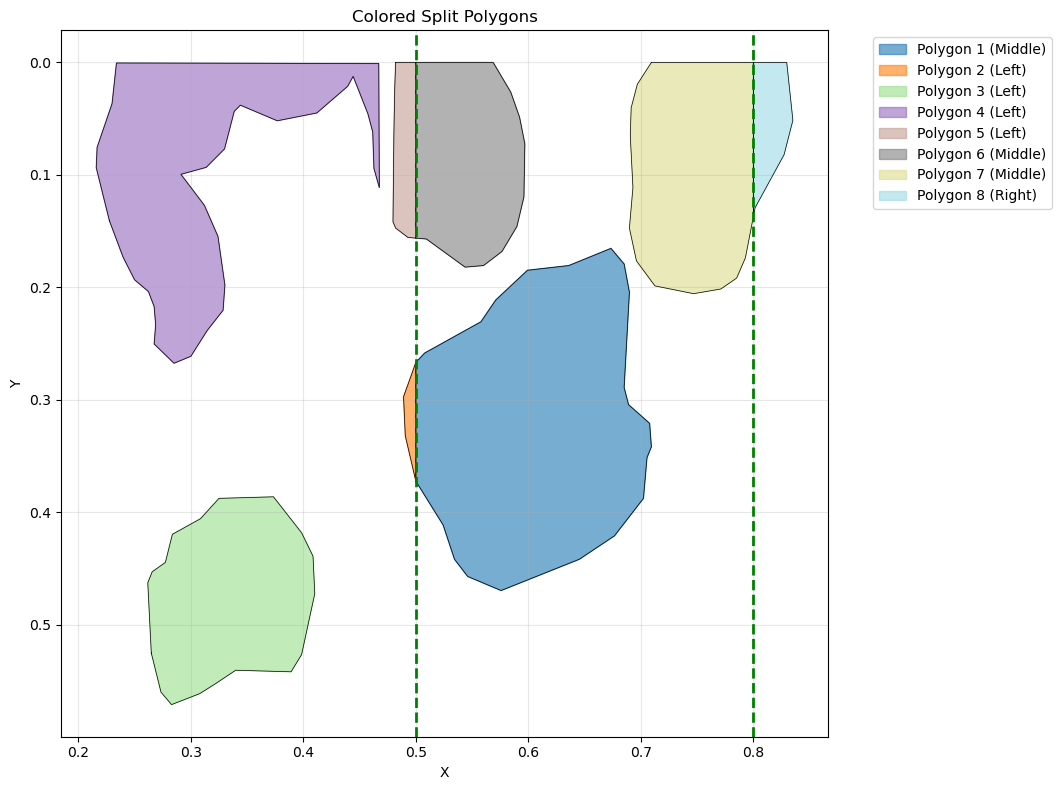

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, LineString, MultiPolygon
from shapely.ops import split
from matplotlib.colors import ListedColormap

def parse_data(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()

    polygons = []
    current_polygon = []

    for line in lines:
        data = line.strip().split(" ")[1:]  # Удаляем первый элемент
        if not data:  # Если строка пустая, пропускаем
            continue
        
        coords = list(map(float, data))
        current_polygon.extend(zip(coords[::2], coords[1::2]))  # Пара (x, y)

        if line.startswith('0'):
            if current_polygon:
                polygons.append(Polygon(current_polygon))
                current_polygon = []

    if current_polygon:
        polygons.append(Polygon(current_polygon))

    return polygons

def create_halses(polygon, spacing):
    minx, miny, maxx, maxy = polygon.bounds
    halses = []
    x = minx
    while x <= maxx:
        line = LineString([(x, miny), (x, maxy)])
        intersection = polygon.intersection(line)
        if intersection.is_empty:
            x += spacing
            continue
        if intersection.geom_type == 'MultiLineString':
            for geom in intersection.geoms:
                halses.append(geom)
        elif intersection.geom_type == 'LineString':
            halses.append(intersection)
        x += spacing
    return halses

def split_polygon_with_lines(polygon):
    split_lines = [
        LineString([(0.5, polygon.bounds[1]), (0.5, polygon.bounds[3])]),
        LineString([(0.8, polygon.bounds[1]), (0.8, polygon.bounds[3])])
    ]
    
    result = [polygon]
    
    for split_line in split_lines:
        temp = []
        for geom in result:
            if geom.geom_type not in ['Polygon', 'MultiPolygon']:
                continue
                
            if geom.intersects(split_line):
                try:
                    parts = split(geom, split_line)
                    if parts.geom_type == 'MultiPolygon':
                        temp.extend(parts.geoms)
                    elif parts.geom_type == 'GeometryCollection':
                        for part in parts.geoms:
                            if part.geom_type == 'Polygon':
                                temp.append(part)
                    else:
                        temp.append(parts)
                except:
                    temp.append(geom)
            else:
                temp.append(geom)
        result = temp
    
    # Фильтруем только непустые полигоны
    return [geom for geom in result if geom.geom_type == 'Polygon' and not geom.is_empty]

def determine_section(polygon):
    minx, _, maxx, _ = polygon.bounds
    if maxx <= 0.5:
        return "Left"
    elif minx >= 0.8:
        return "Right"
    else:
        return "Middle"

def plot_colored_polygons(polygons):
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Создаем цветовую карту
    colors = plt.cm.tab20(np.linspace(0, 1, len(polygons)))
    
    for i, polygon in enumerate(polygons):
        x, y = polygon.exterior.xy
        ax.fill(x, y, color=colors[i], alpha=0.6, label=f'Polygon {i+1} ({determine_section(polygon)})')
        ax.plot(x, y, color='black', linewidth=0.5)
    
    # Разделительные линии
    ax.axvline(x=0.5, color='green', linestyle='--', linewidth=2)
    ax.axvline(x=0.8, color='green', linestyle='--', linewidth=2)
    
    ax.set_aspect('equal')
    plt.title('Colored Split Polygons')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid(True, alpha=0.3)
    plt.gca().invert_yaxis()
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Основной код
file_path = '.ipynb_checkpoints/PrujectNN/example_lables/f1_2759_jpg.rf.a158e3f8e17acb7e2c37fb5070ed1431.txt'
polygons = parse_data(file_path)

# Разделяем полигоны
split_polygons = []
for polygon in polygons:
    split_polygons.extend(split_polygon_with_lines(polygon))

# Создаем график с цветными полигонами
if split_polygons:
    print("Creating colored polygons plot...")
    plot_colored_polygons(split_polygons)
else:
    print("No polygons to display!")

Enter brush radius:  0.03
